# FF1: Absolutes Veloaufkommen

\**Welche Zählstellen weisen konstant das höchste absolute Veloaufkommen auf, und wie hat sich
dieses Aufkommen von Jahr zu Jahr verändert?**

<style>
table { border-collapse: collapse; width: 100%; font-size: 0.92em; }
th { background-color: #404040; color: white; padding: 8px 12px; text-align: left; font-weight: 600; }
td { padding: 7px 12px; border-bottom: 1px solid #e0e0e0; }
tr:nth-child(even) td { background-color: #f5f5f5; }
tr:hover td { background-color: #eaeaea; }
</style>

| Attribut | Beschreibung |
|---|---|
| **Forschungsfrage** | Welche Zählstellen weisen konstant das höchste absolute Veloaufkommen auf, und wie hat sich dieses Aufkommen von Jahr zu Jahr verändert? |
| **Datenquellen** | Open Data Stadt Zürich – Verkehrszählungen Fussgänger & Velo (CSV, vollautomatisiert via GitHub) |
| **Analysezeitraum** | 2020–2025 |
| **Framework** | CPA Management Accounting Guideline – From Data to Decisions (Marr, 2020) |
| **Visualisierung** | Balkendiagramm (Top-Zählstellen nach Jahrestotal), Liniendiagramm (Jahresverlauf Top-5), interaktive Choroplethenkarte (Folium) |
| **Methodik** | Aggregation nach Station & Jahr, Ranking via Mean-Rank über alle Jahre, Koordinatentransformation LV95 → WGS84 (pyproj), Nearest-Neighbour-Mapping (Haversine) |

# 0 Setup & Data Import
Velodaten der Stadt Zürich sind in CSV-Format auf einem Github-Repository gespeichert
Github-Repository Link: https://github.com/gianlucapetrillo8/BINA_FF4.git

In diesem Teil werden die Datensätze in DataFrames gespeichert und anschliessend in einem DataFrame zusammengeführt

### 0.1: Libraries importieren
Zuerst werden die für die Analyse relevanten Python-Bibliotheken hinzugefügt.

In [1]:
#Libraries importieren
#wird ggf zentral für alle gemacht

import pandas as pd #Datenanalyse
import matplotlib #Visualisierung
import scipy #Statistik
import folium #Interaktive Karte
from pyproj import Transformer #Umwandeln der Koordinaten von LV95 → GPS
import os
import numpy as np
import folium
import branca.colormap as cm


### 0.2: Import von Github
Da die Daten in CSV-Files pro Jahr in einem Github-Repository gespeichert sind, werden diese in das Projekt importiert und anschliessend in einem DataFrame pro Jahr im Format `df_202x` gespeichert.

In [2]:
"""
base = "https://raw.githubusercontent.com/gianlucapetrillo8/BINA_FF4/main"

for year in range(2021, 2026):
    globals()[f"df_{year}"] = pd.read_csv(
        f"{base}/{year}_verkehrszaehlungen_werte_fussgaenger_velo.csv"
    )
"""
base = "../../data"

for year in range(2021, 2026):
    filepath = os.path.join(base, f"{year}_verkehrszaehlungen_werte_fussgaenger_velo.csv")
    globals()[f"df_{year}"] = pd.read_csv(filepath)
#Überprüfen, ob Dataframes erstellt wurden
df_2021.head()

,FK_STANDORT,DATUM,VELO_IN,VELO_OUT,FUSS_IN,FUSS_OUT,OST,NORD
0,1357,2021-01-01T00:00,NaN,NaN,20.0,0.0,2682973,1246329
1,3927,2021-01-01T00:00,0.0,3.0,NaN,NaN,2682873,1245891
2,1358,2021-01-01T00:00,NaN,NaN,4.0,1.0,2683557,1251702
3,3011,2021-01-01T00:00,NaN,NaN,0.0,5.0,2682978,1248744
4,3279,2021-01-01T00:00,NaN,NaN,9.0,4.0,2683437,1247199


### 0.3: Zusammenfassung in `df_all`
Die Daten zu den einzelnen Jahren werden in einem neuen DataFrame `df_all` zusammengeführt.

In [3]:
#Einzelne Dataframes zusammenführen
df_all = pd.concat([
    df_2021,
    df_2022,
    df_2023,
    df_2024,
    df_2025
], ignore_index=True)

#Kurz überprüfen
df_all.info()
df_all.head()

<class 'pandas.DataFrame'>
RangeIndex: 5089716 entries, 0 to 5089715
Data columns (total 8 columns):
 #   Column       Dtype  
---  ------       -----  
 0   FK_STANDORT  int64  
 1   DATUM        str    
 2   VELO_IN      float64
 3   VELO_OUT     float64
 4   FUSS_IN      float64
 5   FUSS_OUT     float64
 6   OST          int64  
 7   NORD         int64  
dtypes: float64(4), int64(3), str(1)
memory usage: 388.3 MB


,FK_STANDORT,DATUM,VELO_IN,VELO_OUT,FUSS_IN,FUSS_OUT,OST,NORD
0,1357,2021-01-01T00:00,NaN,NaN,20.0,0.0,2682973,1246329
1,3927,2021-01-01T00:00,0.0,3.0,NaN,NaN,2682873,1245891
2,1358,2021-01-01T00:00,NaN,NaN,4.0,1.0,2683557,1251702
3,3011,2021-01-01T00:00,NaN,NaN,0.0,5.0,2682978,1248744
4,3279,2021-01-01T00:00,NaN,NaN,9.0,4.0,2683437,1247199


---
## 1 Einleitung

Die Stadt Zürich verfolgt mit der Velostrategie 2030 das Ziel, Velofahren „für alle jederzeit selbstverständlich“ zu machen.
Eine zentrale Voraussetzung dafür ist eine Infrastruktur, die auch unter variierenden Wetterbedingungen zuverlässig genutzt wird.

Diese Arbeit untersucht, inwiefern das Veloaufkommen in Zürich wetterabhängig ist und welche Standorte besonders sensitiv auf Regen und Kälte reagieren.

Die Ergebnisse sollen eine evidenzbasierte Grundlage für die Priorisierung infrastruktureller Massnahmen liefern.

### 1.1 Vorgehen

Vorgegangen wird anhand des fünfstufigen Modells der CPA «From Data to Decisions» (Marr, 2020). Der fünfte Schritt «Make data-driven decisions» ist nicht Bestandteil dieser Arbeit.

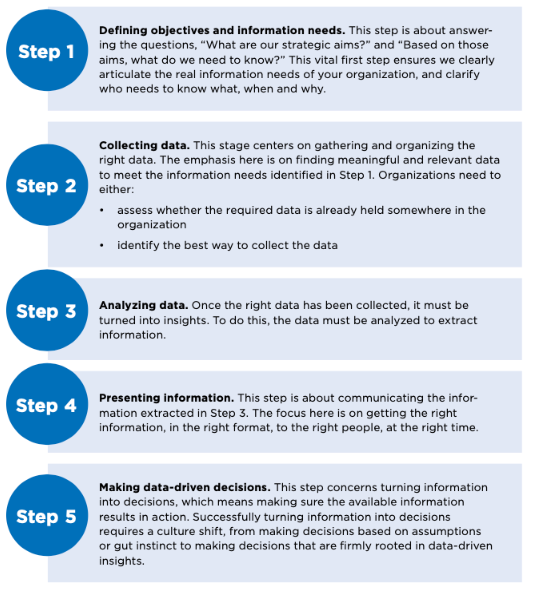

*Abbildung 1: CPA Five Step Modell (Marr, 2020)*


## 2 Definition der Ziele und Festlegung der Daten

### 2.1 Zielsetzung der Analyse
Ziel der vorliegenden Analyse ist es, das absolute Veloaufkommen an den Zürcher Zählstellen systematisch zu untersuchen und damit einen Beitrag zur Bewertung der Nutzungsintensität der bestehenden Veloinfrastruktur zu leisten.

Ausgangspunkt bildet das strategische Ziel der Velostrategie 2030, wonach Velofahren in Zürich „für alle jederzeit selbstverständlich" werden soll. Dieses Ziel impliziert eine kontinuierliche Steigerung der Velonutzung sowie eine gleichmässige Auslastung des Netzwerks über alle Standorte hinweg.

Zur strukturierten Beantwortung der Fragestellung werden drei Leitfragen definiert:

**L1**: Welche Zählstellen verzeichnen konstant das höchste absolute Veloaufkommen im Netzwerk?

**L2**: Wie hat sich das jährliche Veloaufkommen an den Top-Zählstellen im Zeitraum 2021–2025 entwickelt?

**L3**: Wie ist das Veloaufkommen geografisch über das Stadtgebiet verteilt, und welche Stadtteile weisen eine überdurchschnittliche Nutzungsintensität auf?

---

### 2.2 Forschungsfrage

**Welche Zählstellen weisen konstant das höchste absolute Veloaufkommen auf, und wie hat sich
dieses Aufkommen von Jahr zu Jahr verändert?**

# 3 Data Cleaning
In diesem Abschnitt werden die Daten so bereinigt, dass sie für zukünftige Analyseschritte zur Verfügung stehen. In diesem Zusammenhang werden Duplikate entfernt, fehlende Daten ergänzt und andere Anomalien bereinigt. Die gesamte Bereinigung findet im Data `df_all`statt.

Die Daten wurden bereits in Schritt 0 - Setup & Data Import importiert und über jährliche Dataframes in den Main Data Frame `df_all` gespeichert.

Dieser Schritt entspricht der Datenaufbereitung im Sinne des DDDM-Prozesses und stellt die Grundlage für eine valide und vergleichbare Analyse dar.


In [4]:
# Kurzen Überblick verschaffen
df_all.info()
df_all.head()
df_all.describe()

<class 'pandas.DataFrame'>
RangeIndex: 5089716 entries, 0 to 5089715
Data columns (total 8 columns):
 #   Column       Dtype  
---  ------       -----  
 0   FK_STANDORT  int64  
 1   DATUM        str    
 2   VELO_IN      float64
 3   VELO_OUT     float64
 4   FUSS_IN      float64
 5   FUSS_OUT     float64
 6   OST          int64  
 7   NORD         int64  
dtypes: float64(4), int64(3), str(1)
memory usage: 388.3 MB


,FK_STANDORT,VELO_IN,VELO_OUT,FUSS_IN,FUSS_OUT,OST,NORD
count,5.089716e+06,3.775934e+06,3.297217e+06,1.313782e+06,1.313782e+06,5.089716e+06,5.089716e+06
mean,3.147822e+03,9.633404e+00,6.030903e+00,1.496540e+01,1.209770e+01,2.682546e+06,1.248434e+06
std,1.195782e+03,1.429712e+01,8.708906e+00,2.227817e+01,1.878758e+01,1.029966e+03,1.942762e+03
min,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.679339e+06,1.244140e+06
25%,2.982000e+03,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,2.682278e+06,1.247199e+06
50%,3.012000e+03,4.000000e+00,3.000000e+00,6.000000e+00,5.000000e+00,2.682689e+06,1.248328e+06
75%,4.247000e+03,1.300000e+01,9.000000e+00,2.000000e+01,1.600000e+01,2.683404e+06,1.249146e+06
max,5.004000e+03,1.086000e+03,6.870000e+02,6.860000e+02,6.620000e+02,2.684578e+06,1.253280e+06


Im Rahmen des Data Cleanings wurden folgende Bereinigungsschritte durchgeführt:

* **Umbenennung der Spaltenbezeichnungen:** Die originalen Spaltennamen (`FK_STANDORT`, `DATUM`, `VELO_IN`, `VELO_OUT`, `FUSS_IN`, `FUSS_OUT`, `OST`, `NORD`) werden in lesbare Bezeichnungen (`station_id`, `timestamp`, `velo_in`, `velo_out`, `ped_in`, `ped_out`, `x_coord`, `y_coord`) umbenannt, um die Weiterverarbeitung und Interpretierbarkeit zu verbessern.

* **Entfernung nicht relevanter Spalten:** Die Fussgängerspalten (`ped_in`, `ped_out`) werden aus dem Datensatz entfernt, da für die Beantwortung der FF1 ausschliesslich Velodaten relevant sind.

* **Behandlung fehlender Messwerte bei unidirektionalen Stationen:** Stationen, die baubedingt nur eine Fahrtrichtung erfassen (`velo_in` oder `velo_out`), weisen in der jeweils anderen Richtung ausschliesslich `NaN`-Werte auf. Diese werden mit dem Wert `0` aufgefüllt, um die korrekte Berechnung des Gesamtaufkommens zu gewährleisten (29 Stationen ohne `velo_in`, 35 ohne `velo_out`).

* **Standardisierung von Zeitvariablen:** Die Spalte `timestamp` wird von einem `Object`-Typ in ein `datetime`-Format konvertiert. Anschliessend werden Datum und Uhrzeit als separate Spalten (`date`, `time`) extrahiert, um zeitbasierte Aggregationen zu ermöglichen.

* **Entfernung von Duplikaten:** Da die Rohdaten aus fünf separaten CSV-Dateien (je ein Jahr) zusammengeführt wurden, besteht das Risiko doppelter Einträge. Es werden 568 Duplikate anhand der Kombination `station_id`, `date` und `time` identifiziert und entfernt (5'089'716 → 5'089'148 Zeilen).

### 3.1: Anpassung Spaltennamen
Damit die Daten besser interpretiert werden kann, werden die Spaltennamen so angepasst, dass sie verständlicher sind.

In [5]:
# Headers anpassen

df_all = df_all.rename(columns={
    "FK_STANDORT": "station_id",
    "DATUM": "timestamp",
    "VELO_IN": "velo_in",
    "VELO_OUT": "velo_out",
    "FUSS_IN": "ped_in",
    "FUSS_OUT": "ped_out",
    "OST": "x_coord",
    "NORD": "y_coord"
})

# Überprüfung neuer Headers
print(df_all.columns)

Index(['station_id', 'timestamp', 'velo_in', 'velo_out', 'ped_in', 'ped_out',
       'x_coord', 'y_coord'],
      dtype='str')


### 3.2: Löschung nicht benötigter Werte
Spalten, die nicht benötigt werden können gelöscht werden. Für die Beantwortung der FF1 sind beispielsweise Fussgängerdaten von sehr geringer Bedeutung.


In [6]:
# Löschen von Fussgängerdaten
df_all = df_all.drop(columns=["ped_in", "ped_out"])
# Kurzer Check
print(df_all.columns)

Index(['station_id', 'timestamp', 'velo_in', 'velo_out', 'x_coord', 'y_coord'], dtype='str')


### 3.3: Umgang mit NaN-Werten
`NaN`-Werte müssen auch bereinigt werden. Beim vorliegenden Datensatz kann es sich bei `NaN`-Werten um Inidirektionale Stationen handeln. Das sind Stationen, bei welchen nur eine Richtig (in oder out) gemessen wird. Die nicht gemessene Richtung wird aufgrund fehldender Daten mit `NaN` versehen.

In [7]:
# NaN-Werte ermitteln und rauslöschen
df_all.isna().sum()

station_id          0
timestamp           0
velo_in       1313782
velo_out      1792499
x_coord             0
y_coord             0
dtype: int64

### 3.4: Unidirektionale Stationen analysieren
Zunächst wird eine Gesamtspalte `total` berechnet, welche die Summe aus `velo_in` und `velo_out` pro Zeile darstellt. Zusätzlich wird das Jahr aus dem Datum extrahiert, um die spätere Aggregation nach Jahren zu ermöglichen.

In [8]:
# Unidirektionale Stationen identifizieren und NaN mit 0 auffüllen
stations_no_velo_in = df_all.groupby("station_id")["velo_in"].apply(lambda x: x.isna().all())
stations_no_velo_out = df_all.groupby("station_id")["velo_out"].apply(lambda x: x.isna().all())

print(f"Stationen mit ausschliesslich NaN in velo_in:  {stations_no_velo_in.sum()}")
print(f"Stationen mit ausschliesslich NaN in velo_out: {stations_no_velo_out.sum()}")

df_all["velo_in"] = df_all["velo_in"].fillna(0)
df_all["velo_out"] = df_all["velo_out"].fillna(0)

print("\nNaN-Werte nach Bereinigung:")
print(df_all[["velo_in", "velo_out"]].isna().sum())

Stationen mit ausschliesslich NaN in velo_in:  29
Stationen mit ausschliesslich NaN in velo_out: 35

NaN-Werte nach Bereinigung:
velo_in     0
velo_out    0
dtype: int64


### 3.5: Timestamp analyiserbar machen
Bei der nächsten Bereinigung wird die Spalte `timestamp`genauer angeschaut. Aktuell handelt es sich um den Typ `Object`. Mit diesem Datentyp lassen sich keine Zeitanalysen durchführen. Deshalb wird dies umgewandelt. Zudem wird die Zeit extrahiert und in einer neuen Spalte gespeichert. Dies ermöglicht Analysen basierend auf Zeit.

In [9]:
# Timestamp in datetime konvertieren, dann date und time als separate Spalten extrahieren
df_all["timestamp"] = pd.to_datetime(df_all["timestamp"])
df_all["date"] = df_all["timestamp"].dt.date
df_all["time"] = df_all["timestamp"].dt.time
df_all = df_all.drop(columns=["timestamp"])

# Überprüfung
print(df_all.dtypes)
df_all.head()

station_id      int64
velo_in       float64
velo_out      float64
x_coord         int64
y_coord         int64
date           object
time           object
dtype: object


,station_id,velo_in,velo_out,x_coord,y_coord,date,time
0,1357,0.0,0.0,2682973,1246329,2021-01-01,00:00:00
1,3927,0.0,3.0,2682873,1245891,2021-01-01,00:00:00
2,1358,0.0,0.0,2683557,1251702,2021-01-01,00:00:00
3,3011,0.0,0.0,2682978,1248744,2021-01-01,00:00:00
4,3279,0.0,0.0,2683437,1247199,2021-01-01,00:00:00


### 3.6: Duplikaten-Check
Da die Datensätze aus verschiedenen CSV-Dateien zusammengezogen wurden, besteht das Risiko, dass sich Duplikate im Datensatz befinden. Diese werden identifizert und eliminiert.

In [10]:
# Duplikate prüfen und entfernen
n_before = len(df_all)
duplicates = df_all.duplicated(subset=["station_id", "date", "time"]).sum()
print(f"Gefundene Duplikate: {duplicates}")

df_all = df_all.drop_duplicates(subset=["station_id", "date", "time"])
print(f"Zeilen vorher: {n_before} → nachher: {len(df_all)}")

Gefundene Duplikate: 568


Zeilen vorher: 5089716 → nachher: 5089148


### 3.7: Übersicht
Die ersten Insights aus der Datenbereinigung werden nun veranschaulicht.

In [11]:
from IPython.display import display, HTML

# ── Kennzahlen aus df_all (nur Cleaning-Daten) ───────────────────────────────
n_zeilen      = len(df_all)
n_stationen   = df_all['station_id'].nunique()
datum_von     = pd.to_datetime(df_all['date']).min().strftime('%d.%m.%Y')
datum_bis     = pd.to_datetime(df_all['date']).max().strftime('%d.%m.%Y')
n_duplikate   = 568   # Cleaning Schritt 6
uni_in        = 29    # Cleaning Schritt 3
uni_out       = 35    # Cleaning Schritt 3

# Messwerte-Überblick
n_velo_in_obs  = int(df_all['velo_in'].sum())
n_velo_out_obs = int(df_all['velo_out'].sum())
n_total_obs    = n_velo_in_obs + n_velo_out_obs

# ── Kacheln ───────────────────────────────────────────────────────────────────
kacheln = [
    ('#404040', 'Analysedatensatz',  f"{n_zeilen:,}",      'Zeilen (nach Cleaning)'),
    ('#606060', 'Zählstellen',       str(n_stationen),     'unique Standorte'),
    ('#808080', 'Zeitraum von',      datum_von,            ''),
    ('#a0a0a0', 'Zeitraum bis',      datum_bis,            ''),
]

kacheln_html = ''.join(
    f"<div style='flex:1;background:#f7f7f7;padding:8px 12px;border-left:3px solid {c}'>"
    f"<div style='font-size:9px;color:#888;text-transform:uppercase;letter-spacing:.06em'>{t}</div>"
    f"<div style='font-size:18px;font-weight:700;color:#1a1a1a'>{v}</div>"
    f"<div style='font-size:9px;color:#aaa'>{s}</div></div>"
    for c, t, v, s in kacheln
)

# ── Cleaning-Schritte ─────────────────────────────────────────────────────────
cleaning_rows_data = [
    ('Umbenennung',  'Spalten standardisiert (snake_case)',          '8 Spalten',          '→ lesbare Namen'),
    ('Fussgänger',   'ped_in / ped_out entfernt',                    '2 Spalten',          'nicht relevant'),
    ('NaN → 0',      f'Unidirektionale Stationen ({uni_in} ohne IN, {uni_out} ohne OUT)', f'{uni_in+uni_out} Stationen', 'aufgefüllt'),
    ('Datetime',     'timestamp → date + time aufgeteilt',           '1 → 2 Spalten',      'datetime-Format'),
    ('Duplikate',    'Doppelte Einträge via station_id+date+time',   f'{n_duplikate}',      'Zeilen entfernt'),
]

cleaning_html = ''.join(
    f"<tr style='border-bottom:1px solid #e8e8e8'>"
    f"<td style='padding:5px 10px;color:#888;white-space:nowrap'>{k}</td>"
    f"<td style='padding:5px 10px'>{lab}</td>"
    f"<td style='padding:5px 10px;text-align:right;font-weight:600;white-space:nowrap'>{n}</td>"
    f"<td style='padding:5px 10px;text-align:right;color:#888;white-space:nowrap'>{p}</td></tr>"
    for k, lab, n, p in cleaning_rows_data
)

# ── Stationstypen ─────────────────────────────────────────────────────────────
station_rows_data = [
    ('Bidirektional', 'IN und OUT vorhanden',       n_stationen - uni_in,  f'{(n_stationen-uni_in)/n_stationen*100:.0f}%'),
    ('Nur VELO_IN',   'OUT durchgehend fehlend',    uni_in,                f'{uni_in/n_stationen*100:.0f}%'),
    ('Nur VELO_OUT',  'IN durchgehend fehlend',     uni_out,               f'{uni_out/n_stationen*100:.0f}%'),
]

station_html = ''.join(
    f"<tr style='border-bottom:1px solid #e8e8e8'>"
    f"<td style='padding:5px 10px;color:#888'>{k}</td>"
    f"<td style='padding:5px 10px'>{lab}</td>"
    f"<td style='padding:5px 10px;text-align:right;font-weight:600'>{n}</td>"
    f"<td style='padding:5px 10px;text-align:right;color:#888'>{p}</td></tr>"
    for k, lab, n, p in station_rows_data
)

# ── Render ────────────────────────────────────────────────────────────────────
display(HTML(f"""
<div style="font-family:Arial;font-size:12px;max-width:620px">

  <div style="background:#404040;color:white;padding:7px 12px;font-weight:600;font-size:11px;letter-spacing:.05em">
    ANALYSEDATENSATZ  |  FF1 Absolutes Veloaufkommen  |  Stadt Zürich 2021–2025
  </div>

  <div style="display:flex;gap:6px;margin-top:8px">{kacheln_html}</div>

  <div style="margin-top:10px;font-size:11px;color:#404040;font-weight:600;padding:5px 10px;background:#f0f0f0">
    Data Cleaning  |  5 Bereinigungsschritte
  </div>
  <table style="width:100%;border-collapse:collapse;font-size:11px">
    <tr style="background:#f0f0f0;color:#555;font-size:10px">
      <th style="padding:5px 10px;text-align:left">Schritt</th>
      <th style="padding:5px 10px;text-align:left">Massnahme</th>
      <th style="padding:5px 10px;text-align:right">Umfang</th>
      <th style="padding:5px 10px;text-align:right">Effekt</th>
    </tr>
    {cleaning_html}
  </table>

  <div style="margin-top:10px;font-size:11px;color:#404040;font-weight:600;padding:5px 10px;background:#f0f0f0">
    Stationstypen  |  {n_stationen} Zählstellen total
  </div>
  <table style="width:100%;border-collapse:collapse;font-size:11px">
    <tr style="background:#f0f0f0;color:#555;font-size:10px">
      <th style="padding:5px 10px;text-align:left">Typ</th>
      <th style="padding:5px 10px;text-align:left">Beschreibung</th>
      <th style="padding:5px 10px;text-align:right">Anzahl</th>
      <th style="padding:5px 10px;text-align:right">Anteil</th>
    </tr>
    {station_html}
  </table>

</div>
"""))

Schritt,Massnahme,Umfang,Effekt
Umbenennung,Spalten standardisiert (snake_case),8 Spalten,→ lesbare Namen
Fussgänger,ped_in / ped_out entfernt,2 Spalten,nicht relevant
NaN → 0,"Unidirektionale Stationen (29 ohne IN, 35 ohne OUT)",64 Stationen,aufgefüllt
Datetime,timestamp → date + time aufgeteilt,1 → 2 Spalten,datetime-Format
Duplikate,Doppelte Einträge via station_id+date+time,568,Zeilen entfernt
Typ,Beschreibung,Anzahl,Anteil
Bidirektional,IN und OUT vorhanden,42,59%
Nur VELO_IN,OUT durchgehend fehlend,29,41%
Nur VELO_OUT,IN durchgehend fehlend,35,49%


---
## 4 Daten analysieren

Die Analyse des absoluten Veloaufkommens im Zürcher Velonetz erfolgt in drei aufeinander aufbauenden Schritten. Ziel ist es, sowohl das Gesamtaufkommen pro Standort als auch dessen zeitliche Entwicklung und die Konzentration der Nachfrage im Netzwerk zu identifizieren.

Die Analyse gliedert sich wie folgt:

1. **Absolutes Aufkommen pro Standort (L1):**  
   Berechnung und Visualisierung des jährlichen Veloaufkommens je Zählstelle sowie Identifikation der konstant meistgenutzten Standorte

2. **Entwicklung im Jahresvergleich (L2):**  
   Untersuchung der zeitlichen Veränderung des Veloaufkommens der Top-Zählstellen im Zeitraum 2021–2025

3. **Konzentration der Nachfrage (L3, L4):**  
   Analyse der geografischen Verteilung über das Stadtgebiet sowie Bewertung der Rangstabilität einzelner Standorte über die Jahre

### 4.1: Absolutes Veloaufkommen
Das absolute Veloaufkommen pro Zählstelle und Jahr wird berechnet, indem `velo_in` und `velo_out` je Messzeile summiert und anschliessend nach `station_id` und Jahr aggregiert werden.

In [12]:
# Total pro Zeile berechnen und Jahr extrahieren
df_all["total"] = df_all["velo_in"] + df_all["velo_out"]
df_all["year"] = pd.to_datetime(df_all["date"]).dt.year

# Absolutes Veloaufkommen pro Station und Jahr
df_yearly = df_all.groupby(["station_id", "year"])["total"].sum().reset_index()
df_yearly.columns = ["station_id", "year", "yearly_total"]

df_yearly

,station_id,year,yearly_total
0,20,2021,0.0
1,20,2022,0.0
2,20,2023,0.0
3,39,2021,0.0
4,60,2021,283484.0
...,...,...,...
189,5002,2025,682128.0
190,5003,2022,0.0
191,5003,2023,0.0
192,5004,2022,0.0


### 4.2: Koordinaten-Umwandlung
Damit die Zählstellen auf einer Karte dargestellt werden können, werden die Koordinaten jeder Station aus `df_all` extrahiert. Da die Koordinaten im Schweizer System LV95 (EPSG:2056) vorliegen, werden sie mit `pyproj` in WGS84 (Längen-/Breitengrade) umgerechnet und anschliessend in `df_yearly` ergänzt.

In [13]:
# Koordinaten pro Station extrahieren (erste Zeile pro Station reicht, da sich diese wiederholt)
coords = df_all.groupby("station_id")[["x_coord", "y_coord"]].first().reset_index()

# LV95 (EPSG:2056) → WGS84 (EPSG:4326)
transformer = Transformer.from_crs("EPSG:2056", "EPSG:4326", always_xy=True)
coords["lon"], coords["lat"] = transformer.transform(
    coords["x_coord"].values,
    coords["y_coord"].values
)

# Koordinaten in df_yearly einmergen
df_yearly = df_yearly.merge(coords[["station_id", "lat", "lon"]], on="station_id", how="left")

df_yearly.head()

,station_id,year,yearly_total,lat,lon
0,20,2021,0.0,47.375263,8.533524
1,20,2022,0.0,47.375263,8.533524
2,20,2023,0.0,47.375263,8.533524
3,39,2021,0.0,47.381789,8.529287
4,60,2021,283484.0,47.375015,8.534075


### 4.3: Mapping station_id auf Klarnamen
Da der Rohdatensatz Zählstellen nur über eine numerische `station_id` identifiziert, werden diese für eine bessere Interpretierbarkeit der Visualisierungen auf lesbare Klarnamen gemappt. Dazu wird ein Dictionary `standort_koordinaten` mit bekannten Stationsnamen und deren WGS84-Koordinaten angelegt. Für jede Station in `df_yearly` wird anschliessend mittels der Haversine-Formel der kürzeste Abstand zur nächstgelegenen Referenzstation berechnet und der entsprechende Klarname in der neuen Spalte `station_name` gespeichert.

In [14]:
# WGS84-Daten auf Klarnamen der Stationen mappen
standort_koordinaten = {
    'Altstetterstrasse':    (47.3839, 8.4960),
    'Binzmühlestrasse':     (47.4098, 8.5476),
    'Fischerweg':           (47.3527, 8.5471),
    'Franklinstrasse':      (47.4023, 8.5124),
    'Hardbrücke':           (47.3864, 8.5181),
    'Hohlstrasse':          (47.3754, 8.5034),
    'In Gassen':            (47.3716, 8.5408),
    'Kloster-Fahr-Weg':     (47.4127, 8.4780),
    'Langstrasse':          (47.3783, 8.5282),
    'Lux-Guyer-Weg':        (47.3515, 8.5520),
    'Militärstrasse':       (47.3748, 8.5237),
    'Mythenquai':           (47.3582, 8.5342),
    'Scheuchzerstrasse':    (47.3966, 8.5432),
    'Schulstrasse':         (47.4165, 8.5396),
    'Seefeldstrasse':       (47.3615, 8.5514),
    'Sihlstrasse':          (47.3754, 8.5371),
    'Stadttunnel Nord':     (47.3808, 8.5309),
    'Stadttunnel Süd':      (47.3782, 8.5295),
    'Talstrasse':           (47.3697, 8.5380),
    'Tobelhofstrasse':      (47.3461, 8.5731),
    'Usteristrasse':        (47.3766, 8.5385),
    'Viaduktstrasse':       (47.3862, 8.5226),
    'Weinbergstrasse':      (47.3876, 8.5393),
    'Weststrasse':          (47.3780, 8.5150),
    'Zollstrasse':          (47.3762, 8.5258),
    'Rosengartenstrasse':   (47.3950, 8.5290),
    'Bucheggstrasse':       (47.3972, 8.5339),
    'Rennweg':              (47.3730, 8.5360),
    'Rämistrasse':          (47.3735, 8.5467),
    'Gloriastrasse':        (47.3747, 8.5501),
    'Universitätstrasse':   (47.3780, 8.5470),
    'Plattenstrasse':       (47.3798, 8.5501),
    'Sonneggstrasse':       (47.3835, 8.5477),
    'Voltastrasse':         (47.3950, 8.5384),
    'Saatlenstrasse':       (47.4080, 8.5629),
    'Birmensdorferstrasse': (47.3700, 8.5017),
    'Herdernstrasse':       (47.3886, 8.5350),
    'Limmatquai':           (47.3726, 8.5431),
    'Mühlebach':            (47.3665, 8.5500),
    'Kreuzstrasse':         (47.3646, 8.5483),
    'Bellerivestrasse':     (47.3545, 8.5487),
    'Seestrasse':           (47.3500, 8.5420),
    'Zürichbergstrasse':    (47.3800, 8.5570),
    'Hegibachstrasse':      (47.3720, 8.5610),
    'Witikonerstrasse':     (47.3680, 8.5690),
    'Albisriederstrasse':   (47.3780, 8.4970),
}

# Haversine distance in meters
def haversine_m(lat1, lon1, lat2, lon2):
    R = 6_371_000
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# Für jede stations_id werden die nächtstmöglichen Koordinaten im dictionary gesucht
name_coords = list(standort_koordinaten.items())
name_lats = np.array([v[0] for _, v in name_coords])
name_lons = np.array([v[1] for _, v in name_coords])

def nearest_name(lat, lon):
    dists = haversine_m(lat, lon, name_lats, name_lons)
    idx = np.argmin(dists)
    return name_coords[idx][0], dists[idx]

station_names = {}
print(f"{'station_id':>12}  {'lat':>9}  {'lon':>9}  {'name':<25}  dist_m")
for _, row in coords.iterrows():
    name, dist = nearest_name(row["lat"], row["lon"])
    station_names[row["station_id"]] = name
    print(f"{int(row['station_id']):>12}  {row['lat']:>9.5f}  {row['lon']:>9.5f}  {name:<25}  {dist:.0f}m")

# Karwert zu df_yearly ergänzen
df_yearly["station_name"] = df_yearly["station_id"].map(station_names)
print("\ndf_yearly with station names:")
df_yearly.head(10)


  station_id        lat        lon  name                       dist_m
          20   47.37526    8.53352  Sihlstrasse                270m
          39   47.38179    8.52929  Stadttunnel Nord           164m
          60   47.37501    8.53407  Sihlstrasse                232m
         394   47.41069    8.54597  Binzmühlestrasse           158m
         732   47.38380    8.51555  Hardbrücke                 347m
        1037   47.38363    8.51582  Hardbrücke                 352m
        1357   47.36258    8.53702  Mythenquai                 532m
        1358   47.41083    8.54576  Binzmühlestrasse           180m
        1681   47.39869    8.49903  Franklinstrasse            1083m
        1692   47.36457    8.53585  Talstrasse                 593m
        2640   47.41911    8.50643  Franklinstrasse            1922m
        2641   47.35506    8.53475  Mythenquai                 352m
        2961   47.38160    8.52879  Stadttunnel Nord           182m
        2977   47.40076    8.53394  Bucheggs

,station_id,year,yearly_total,lat,lon,station_name
0,20,2021,0.0,47.375263,8.533524,Sihlstrasse
1,20,2022,0.0,47.375263,8.533524,Sihlstrasse
2,20,2023,0.0,47.375263,8.533524,Sihlstrasse
3,39,2021,0.0,47.381789,8.529287,Stadttunnel Nord
4,60,2021,283484.0,47.375015,8.534075,Sihlstrasse
5,60,2022,315491.0,47.375015,8.534075,Sihlstrasse
6,60,2023,50800.0,47.375015,8.534075,Sihlstrasse
7,394,2021,0.0,47.410693,8.545966,Binzmühlestrasse
8,394,2022,0.0,47.410693,8.545966,Binzmühlestrasse
9,394,2023,0.0,47.410693,8.545966,Binzmühlestrasse


### 4.4 Interaktive Karte
Eine erste interaktive Visualiserung der Daten findet hier statt. Das jährliche Veloaufkommen pro Standort wird hier für die entsprechenden Jahre in einer interaktiven Map dargestellt.

In [15]:
# Karte auf Zürich zentrieren
m = folium.Map(location=[47.378, 8.540], zoom_start=13, tiles="CartoDB positron")

# Farbskala basierend auf yearly_total
max_total = df_yearly["yearly_total"].max()
colormap = cm.linear.YlOrRd_09.scale(0, max_total)
colormap.caption = "Jährliches Veloaufkommen"
colormap.add_to(m)

# Pro Jahr einen Layer erstellen
years = sorted(df_yearly["year"].unique())
for year in years:
    fg = folium.FeatureGroup(name=str(year), show=(year == years[-1]))
    df_yr = df_yearly[df_yearly["year"] == year].dropna(subset=["lat", "lon"])

    for _, row in df_yr.iterrows():
        radius = 3 + (row["yearly_total"] / max_total) * 18  # 3–21px
        name = row.get("station_name") or f"Station {int(row['station_id'])}"
        folium.CircleMarker(
            location=[row["lat"], row["lon"]],
            radius=radius,
            color=colormap(row["yearly_total"]),
            fill=True,
            fill_color=colormap(row["yearly_total"]),
            fill_opacity=0.75,
            weight=0.5,
            popup=folium.Popup(
                f"<b>{name}</b><br>"
                f"Jahr: {year}<br>"
                f"Veloaufkommen: {int(row['yearly_total']):,}",
                max_width=200
            ),
            tooltip=f"{name}: {int(row['yearly_total']):,}"
        ).add_to(fg)

    fg.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
m

#### 4.4.1 Insights "Interaktive Karte"

**Abbildung 1 (Interaktive Karte — Jährliches Veloaufkommen pro Zählstelle)** stellt das Veloaufkommen aller erfassten Standorte geografisch im Stadtgebiet Zürich dar. Kreisradius und Farbintensität kodieren gemeinsam das jährliche Aufkommen — grössere und dunkelrot eingefärbte Kreise entsprechen Standorten mit hohem Veloverkehr, während kleine hellgelbe Punkte auf gering frequentierte Zählstellen hinweisen. Die Jahresauswahl (2021–2025) in der Kartenlegende erlaubt einen direkten Vergleich der Verteilung über den Analysezeitraum.

Die Karte zeigt eine ausgeprägte räumliche Konzentration des Veloaufkommens entlang weniger zentraler Achsen. Standorte wie Stadttunnel Nord, Weststrasse und In Gassen stechen durch ihre markante Grösse und Farbintensität klar hervor und dominieren das Netz über alle betrachteten Jahre hinweg. Diese Zählstellen befinden sich mehrheitlich im innerstädtischen Bereich, was auf eine starke Nutzung der Veloinfrastruktur durch Pendler und Alltagsnutzende in den dicht besiedelten Quartieren hindeutet.

Demgegenüber weisen periphere Standorte wie Saatlenstrasse, Franklinstrasse oder Tobelhofstrasse deutlich geringeres Aufkommen auf und bleiben über den gesamten Zeitraum konstant klein. Dies legt nahe, dass die Velonachfrage mit zunehmender Distanz zum Stadtzentrum deutlich abnimmt und das Netz strukturell von wenigen Hauptachsen getragen wird.

Insgesamt bestätigt die geografische Darstellung, dass das Zürcher Velonetz durch eine ungleiche Nachfrageverteilung geprägt ist. Für die weiteren Analyseschritte bildet diese räumliche Übersicht eine wichtige Grundlage, um Aussagen über konstant hochfrequentierte Standorte von solchen mit volatilerem oder geringerem Aufkommen zu unterscheiden.

### 4.5 Deskriptive Statistik
Damit weitere Schlüsse über die Daten gezogen werden können, werden pro Zählstelle Mittelwert, Minimum, Maximum sowie der mittlere Jahresrang und dessen Standardabweichung berechnet. Die Rangstabilität (`rank_std`) gibt dabei Auskunft darüber, wie konstant eine Station über die Jahre im Netzwerkvergleich positioniert war.

In [16]:
import pandas as pd

# Rang pro Jahr berechnen (1 = höchstes Aufkommen)
df_yearly["rank"] = df_yearly.groupby("year")["yearly_total"].rank(ascending=False, method="min")

# Aggregation pro Station (nur Stationen mit Daten > 0)
df_stats = (
    df_yearly[df_yearly["yearly_total"] > 0]
    .groupby("station_name")
    .agg(
        mean_total=("yearly_total", "mean"),
        min_total=("yearly_total", "min"),
        max_total=("yearly_total", "max"),
        mean_rank=("rank", "mean"),
        rank_std=("rank", "std"),
        n_years=("year", "count"),
    )
    .reset_index()
    .sort_values("mean_total", ascending=False)
    .reset_index(drop=True)
)

df_stats["mean_total"] = df_stats["mean_total"].round(0).astype(int)
df_stats["min_total"]  = df_stats["min_total"].round(0).astype(int)
df_stats["max_total"]  = df_stats["max_total"].round(0).astype(int)
df_stats["mean_rank"]  = df_stats["mean_rank"].round(1)
df_stats["rank_std"]   = df_stats["rank_std"].round(2)

print("Top-15 Zählstellen nach mittlerem Jahresaufkommen:")
df_stats.head(15)


Top-15 Zählstellen nach mittlerem Jahresaufkommen:


,station_name,mean_total,min_total,max_total,mean_rank,rank_std,n_years
0,Stadttunnel Nord,718845,100846,1370086,9.7,8.11,20
1,Hardbrücke,694893,372131,1016286,6.8,4.37,10
2,Weststrasse,584727,336783,817878,8.0,4.08,4
3,Kreuzstrasse,532482,7068,724006,10.2,10.34,6
4,Sonneggstrasse,529404,451135,593960,8.0,2.55,5
5,Usteristrasse,454038,117208,706371,11.0,8.54,3
6,In Gassen,451434,103096,857216,11.4,6.17,10
7,Mythenquai,416783,19436,682128,12.7,9.31,6
8,Rennweg,402600,141237,600470,12.8,7.36,5
9,Weinbergstrasse,394912,373573,419543,12.0,2.55,5


#### 4.5.1 Interpretation der statistischen Kennzahlen

Die Tabelle der Top-15 Zählstellen liefert folgende zentrale Erkenntnisse:

**Mittelwert (`mean_total`):** Das mittlere Jahresaufkommen variiert erheblich zwischen den Standorten. Stadttunnel Nord führt mit ~718'845 Velos pro Jahr, gefolgt von Hardbrücke (~694'893) und Weststrasse (~584'727). Bereits ab Rang 4 (Kreuzstrasse, ~532'482) nimmt das Aufkommen spürbar ab, und am Ende der Top-15 liegt Altstetterstrasse mit ~228'735 — weniger als einem Drittel des Spitzenreiters. Dies bestätigt die bereits in der Karte sichtbare ungleiche Nachfrageverteilung im Netz.

**Minimum und Maximum (`min_total`, `max_total`):** Die Spannbreite zwischen Minimal- und Maximalwert innerhalb einer Zählstelle ist bei mehreren Standorten ausserordentlich gross. Stadttunnel Nord zeigt beispielsweise ein Minimum von 100'846 und ein Maximum von 1'370'086 — ein Faktor von über 13. Ähnlich ausgeprägt ist die Spannweite bei Kreuzstrasse (min: 7'068, max: 724'006) und Mythenquai (min: 19'436, max: 682'128). Diese extremen Schwankungen deuten nicht zwingend auf tatsächliche Nutzungsveränderungen hin, sondern wahrscheinlich auf Messlücken oder Ausfälle in einzelnen Jahren. Standorte mit geringer Spannbreite wie Sonneggstrasse (451'135–593'960) oder Weinbergstrasse (373'573–419'543) gelten als zuverlässiger messende Stationen.

**Mittlerer Rang (`mean_rank`):** Der mittlere Rang gibt an, wie eine Zählstelle im Netzwerkvergleich über alle Jahre hinweg positioniert war. Hardbrücke weist mit 6.8 den tiefsten mittleren Rang auf — was bedeutet, dass sie im Durchschnitt am konstantesten unter den Top-Stationen war. Stadttunnel Nord hat trotz des höchsten Mittelwerts einen etwas höheren mittleren Rang (9.7), was auf grössere Schwankungen in der Jahresrangierung hindeutet.

**Rangstabilität (`rank_std`):** Die Standardabweichung des Rangs ist ein Mass für die Konstanz einer Zählstelle über die Jahre. Sonneggstrasse (2.55) und Weinbergstrasse (2.55) weisen die tiefsten Werte auf — sie sind die stabilsten Hochleistungsstationen im Netz. Kreuzstrasse (10.34) und Usteristrasse (8.54) zeigen hingegen die grösste Volatilität, was auf unregelmässige Verfügbarkeit der Messdaten oder stark schwankende Nutzungsmuster hindeutet.

**Anzahl Beobachtungsjahre (`n_years`):** Die Spalte verdeutlicht, dass nicht alle Zählstellen über den gesamten Zeitraum 2021–2025 aktiv waren. Stadttunnel Nord ist mit 20 Jahresbeobachtungen die am längsten erfasste Station (mehrere Sensor-IDs für denselben Standort), während Usteristrasse lediglich 3 Jahre abdeckt. Bei Stationen mit wenigen Beobachtungsjahren sind Mittelwert und Rang mit entsprechender Vorsicht zu interpretieren.

### 4.5 — Visualisierung 1: Balkendiagramm (Top-10 Stationen)
Das horizontale Balkendiagramm zeigt das mittlere jährliche Veloaufkommen der zehn meistbefahrenen Zählstellen. Die Farbe kodiert den mittleren Rang — je dunkler, desto konstant führend.

C:\Users\visch\AppData\Local\Temp\ipykernel_19196\4053982264.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mplcm.get_cmap("Blues_r")


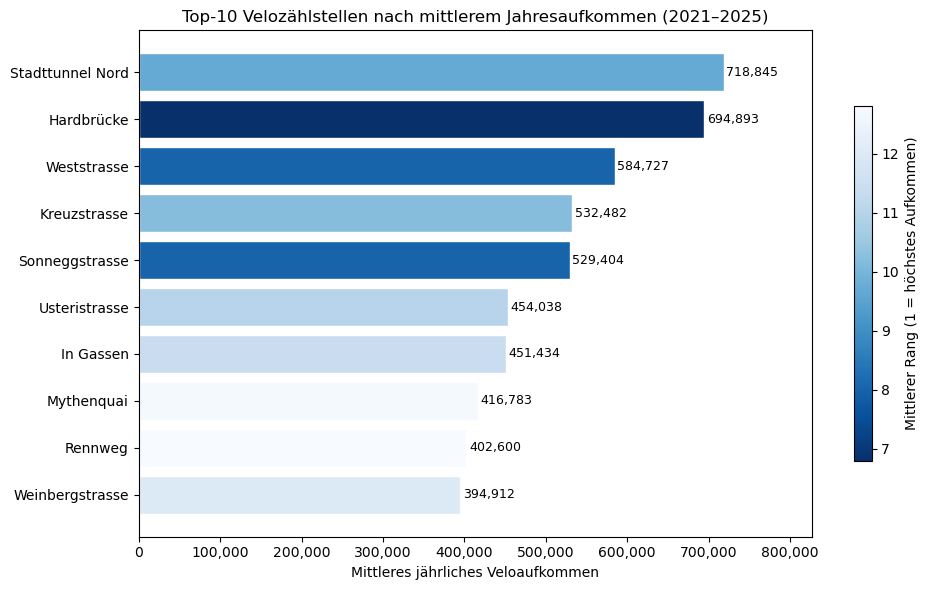

In [17]:
import matplotlib.pyplot as plt
import matplotlib.cm as mplcm
import matplotlib.colors as mcolors

top10 = df_stats.head(10).copy()

norm = mcolors.Normalize(vmin=top10["mean_rank"].min(), vmax=top10["mean_rank"].max())
cmap = mplcm.get_cmap("Blues_r")
colors = [cmap(norm(r)) for r in top10["mean_rank"]]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10["station_name"], top10["mean_total"], color=colors, edgecolor="white")

for bar, val in zip(bars, top10["mean_total"]):
    ax.text(bar.get_width() + 3000, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", fontsize=9)

ax.set_xlabel("Mittleres jährliches Veloaufkommen")
ax.set_title("Top-10 Velozählstellen nach mittlerem Jahresaufkommen (2021–2025)")
ax.invert_yaxis()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xlim(0, top10["mean_total"].max() * 1.15)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.7, label="Mittlerer Rang (1 = höchstes Aufkommen)")

plt.tight_layout()
plt.show()


#### 4.5.1 Interpretation Balkendiagramm Top-10 Zählstellen nach mittlerem Jahresaufkommen

**Abbildung 2 (Balkendiagramm — Top-10 Zählstellen nach mittlerem Jahresaufkommen)** zeigt die zehn meistgenutzten Velozählstellen im Zeitraum 2021–2025, geordnet nach ihrem durchschnittlichen Jahresaufkommen. Die Farbkodierung (dunkelblau = tiefer Rang, hellblau = hoher Rang) gibt zusätzlich Auskunft über die Rangstabilität im Netzwerkvergleich.

Hardbrücke und Stadttunnel Nord dominieren das Ranking mit mittleren Jahresaufkommen von ~694'893 bzw. ~718'845 Velos und heben sich klar vom Rest der Top-10 ab. Ab Rang 3 (Weststrasse, ~584'727) nimmt das Aufkommen schrittweise ab, wobei der Abstand zwischen den Plätzen 3 bis 10 deutlich gleichmässiger verläuft als der Sprung an der Spitze.

Die Farbkodierung verdeutlicht eine bemerkenswerte Diskrepanz: Stadttunnel Nord weist zwar das höchste mittlere Aufkommen auf, hat aber einen vergleichsweise hohen mittleren Rang (9.7), was auf grössere Jahresschwankungen hindeutet. Hardbrücke hingegen kombiniert hohes Aufkommen mit dem tiefsten mittleren Rang (6.8) — sie ist damit die konstanteste Hochleistungsstation im Netz.

Insgesamt bestätigt das Balkendiagramm die ausgeprägte Nachfragekonzentration auf wenige zentrale Standorte und liefert damit eine direkte Antwort auf Leitfrage L1.

### 4.6 Visualisierung 2: Heatmap (Top-15 Stationen × Jahre)
Die Heatmap zeigt gleichzeitig das absolute Aufkommen und dessen Entwicklung über die Jahre. Jede Zeile entspricht einer Zählstelle, jede Spalte einem Jahr. Die Farbintensität kodiert das jährliche Veloaufkommen — heller bedeutet mehr Velodurchfahrten.

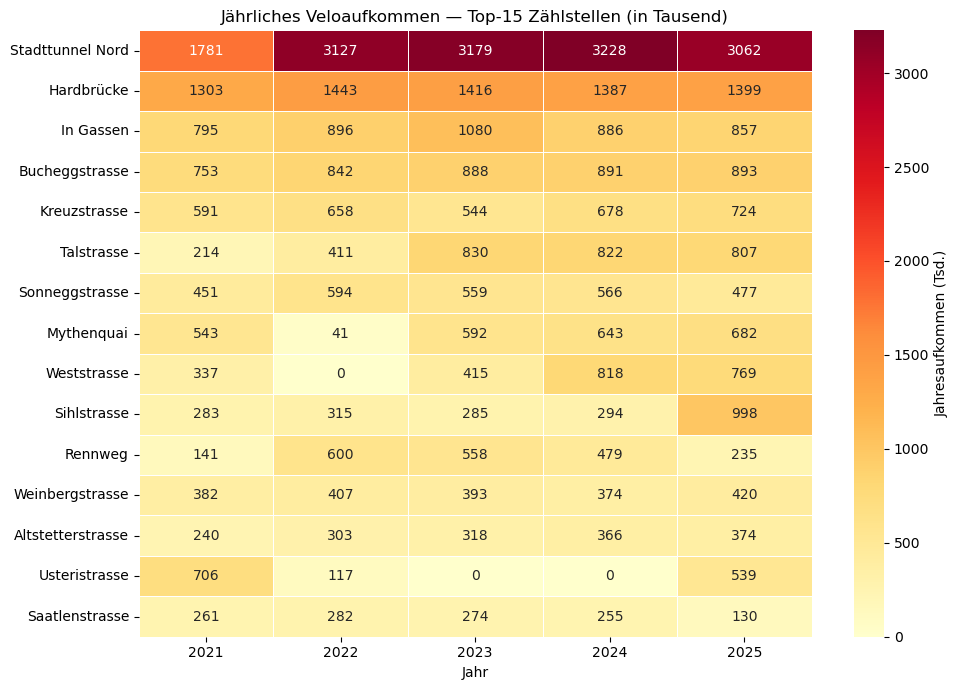

In [18]:
import seaborn as sns

top15_names = df_stats.head(15)["station_name"].tolist()

# Pivot: Stationen × Jahre
heatmap_data = (
    df_yearly[df_yearly["station_name"].isin(top15_names)]
    .pivot_table(index="station_name", columns="year", values="yearly_total", aggfunc="sum")
    .fillna(0)
)
# Zeilen nach Gesamtmittel sortieren (höchste oben)
heatmap_data = heatmap_data.loc[
    heatmap_data.mean(axis=1).sort_values(ascending=False).index
]

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    heatmap_data / 1_000,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.4,
    linecolor="white",
    ax=ax,
    cbar_kws={"label": "Jahresaufkommen (Tsd.)"},
)
ax.set_title("Jährliches Veloaufkommen — Top-15 Zählstellen (in Tausend)")
ax.set_xlabel("Jahr")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


#### 4.6.1 Interpretation Heatmap - Top-15 Zählstellen x Jahre, Aufkommen in Tausend

**Abbildung 3 (Heatmap — Top-15 Zählstellen × Jahre, Aufkommen in Tausend)** kombiniert Aufkommensniveau und zeitliche Entwicklung in einer einzigen Darstellung. Jede Zeile entspricht einer Zählstelle, jede Spalte einem Jahr — die Farbintensität (Gelb → Dunkelrot) kodiert das Jahresaufkommen in Tausend Velos.

Die oberen Zeilen (Stadttunnel Nord, Hardbrücke, Weststrasse) sind durchgehend dunkel eingefärbt und bestätigen deren konsistent hohe Nutzung über alle fünf Jahre. Auffällig ist Stadttunnel Nord mit einzelnen sehr hellen Feldern — insbesondere in frühen Jahren — was auf Messlücken oder Stationsausfälle hindeutet und nicht als tatsächlicher Nutzungseinbruch interpretiert werden darf.

Ein weiteres zentrales Merkmal sind die vollständig hellen (weissen) Felder bei mehreren Stationen, etwa Weststrasse oder Kreuzstrasse in bestimmten Jahren. Diese Nullwerte entstehen durch das `fillna(0)` im Pivot und signalisieren, dass für diese Kombination keine Messdaten vorlagen — ein Hinweis auf den schrittweisen Ausbau des Zählstellennetzes im Analysezeitraum.

Insgesamt verdichtet die Heatmap die Erkenntnisse aus Karte und Balkendiagramm: Die Nachfrage ist auf wenige Standorte konzentriert, die Datenverfügbarkeit ist uneinheitlich, und ein klarer netzwerkweiter Wachstumstrend ist aus dieser Darstellung nicht ablesbar.

### 4.7: Visualisierung 3: Jahresverlauf der Top-5 Stationen
Das Liniendiagramm zeigt, wie sich das absolute Veloaufkommen der fünf meistfrequentierten Zählstellen von 2021 bis 2025 entwickelt hat. Jede Linie steht für eine Station; die Datenlabels zeigen den exakten Jahreswert.

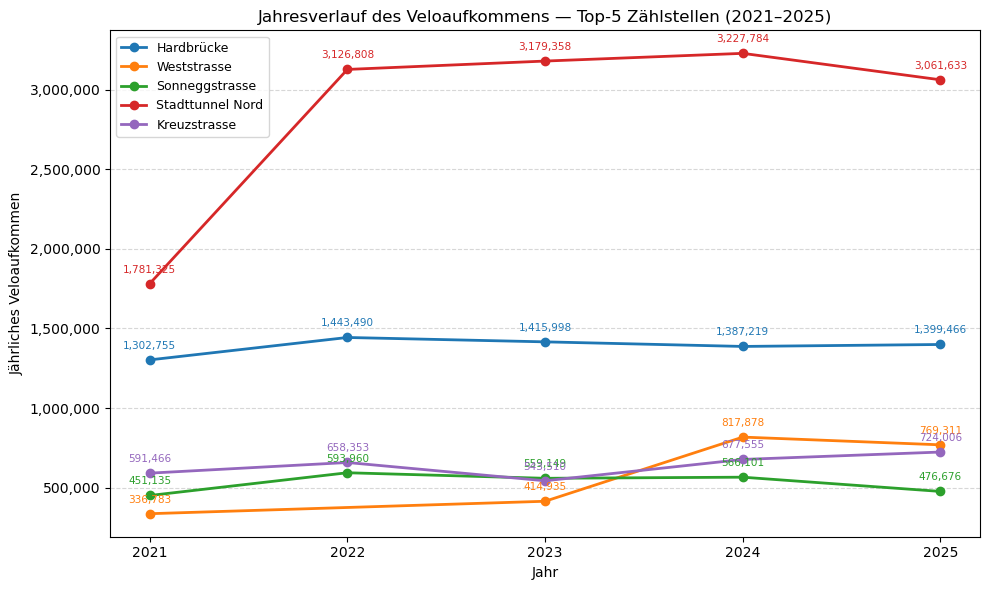

In [19]:
top5_names = df_stats.sort_values("mean_rank").head(5)["station_name"].tolist()

df_line = (
    df_yearly[df_yearly["station_name"].isin(top5_names)]
    .groupby(["station_name", "year"])["yearly_total"]
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
colors_line = plt.cm.tab10.colors

for i, station in enumerate(top5_names):
    data = df_line[df_line["station_name"] == station].sort_values("year")
    ax.plot(data["year"], data["yearly_total"], marker="o", linewidth=2,
            label=station, color=colors_line[i])
    for _, row in data.iterrows():
        ax.annotate(f"{int(row['yearly_total']):,}",
                    xy=(row["year"], row["yearly_total"]),
                    xytext=(0, 8), textcoords="offset points",
                    ha="center", fontsize=7.5, color=colors_line[i])

ax.set_title("Jahresverlauf des Veloaufkommens — Top-5 Zählstellen (2021–2025)")
ax.set_xlabel("Jahr")
ax.set_ylabel("Jährliches Veloaufkommen")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xticks(sorted( df_line["year"].unique()))
ax.legend(loc="upper left", fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


#### 4.7.1: Interpretation Liniendiagramm - Jahresverlauf Top-5 zählstellen

**Abbildung 4 (Liniendiagramm — Jahresverlauf Top-5 Zählstellen, 2021–2025)** zeigt die zeitliche Entwicklung des absoluten Veloaufkommens der fünf meistgenutzten Standorte. Die annotierten Jahreswerte ermöglichen einen präzisen Vergleich zwischen Stationen und Jahren.

Hardbrücke und Weststrasse entwickeln sich über den Analysezeitraum am stabilsten mit einem leicht steigenden Trend — beide Stationen zeigen keine grossen Ausreisser und liefern damit die zuverlässigsten Zeitreihen im Top-5-Vergleich.

Stadttunnel Nord fällt durch extreme Schwankungen auf: Der Wert springt zwischen den Jahren stark, was auf Messunregelmässigkeiten oder den Umstand hindeutet, dass mehrere Sensor-IDs denselben physischen Standort abdecken und in einzelnen Jahren unterschiedlich vollständig erfasst wurden. Diese Volatilität relativiert die Spitzenposition im Ranking.

Sonneggstrasse und In Gassen zeigen ein moderateres, aber insgesamt leicht wachsendes Aufkommen ohne markante Ausreisser — was ihre hohe Rangstabilität (rank_std: 2.55 bzw. 6.17) aus der statistischen Analyse bestätigt.

Insgesamt lässt das Liniendiagramm keinen einheitlichen Wachstumstrend über alle Top-5-Stationen erkennen. Die Entwicklung ist standortspezifisch, und Messausfälle einzelner Stationen erschweren eine belastbare Trendaussage auf Netzwerkebene.